# Local level two ways: scan-based Markov latents vs. `pymc-extras` statespace

The same generative model — a random-walk level observed with noise — can be written in
`pymc_forecast` in two ways:

1. **Scan-based** (`markov_time_series`): the level is an explicit per-step latent sampled
   by NUTS, and the forecast segment is seeded from the final in-sample state.
2. **Statespace** (`pymc_extras.statespace` via `StatespaceForecaster`): the level is a
   linear-Gaussian hidden state that the Kalman filter marginalizes out *exactly*, so NUTS
   only samples the (few) structural parameters.

For linear-Gaussian dynamics the second form should win on both **posterior quality**
(no funnel between the level path and its innovation scale) and **runtime** (a handful of
parameters instead of one latent per time step). This notebook checks that claim on
simulated data with known parameters, and shows that both model kinds run through the same
`backtest` call and metrics.

## Prepare notebook

In [1]:
import logging
from time import perf_counter

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from pymc_extras.statespace import structural as st

from pymc_forecast import (
    HMCForecaster,
    Horizon,
    StatespaceForecaster,
    StatespaceModel,
    backtest,
    evaluate_forecast,
    markov_time_series,
    null_covariates,
    predict,
    results_to_dataframe,
)
from pymc_forecast.data import FUTURE_DIM, TIME_DIM

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pymc_extras").setLevel(logging.ERROR)

SEED = 20260713
rng = np.random.default_rng(SEED)

## Simulate a local-level process

A random-walk level with innovation scale $\sigma_\eta = 0.15$, observed with noise
$\sigma_\varepsilon = 0.3$:

$$
\mu_t = \mu_{t-1} + \eta_t, \qquad \eta_t \sim \mathcal{N}(0, \sigma_\eta), \qquad
y_t = \mu_t + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, \sigma_\varepsilon).
$$

Knowing the true parameters lets us judge the posteriors, not just the forecasts.

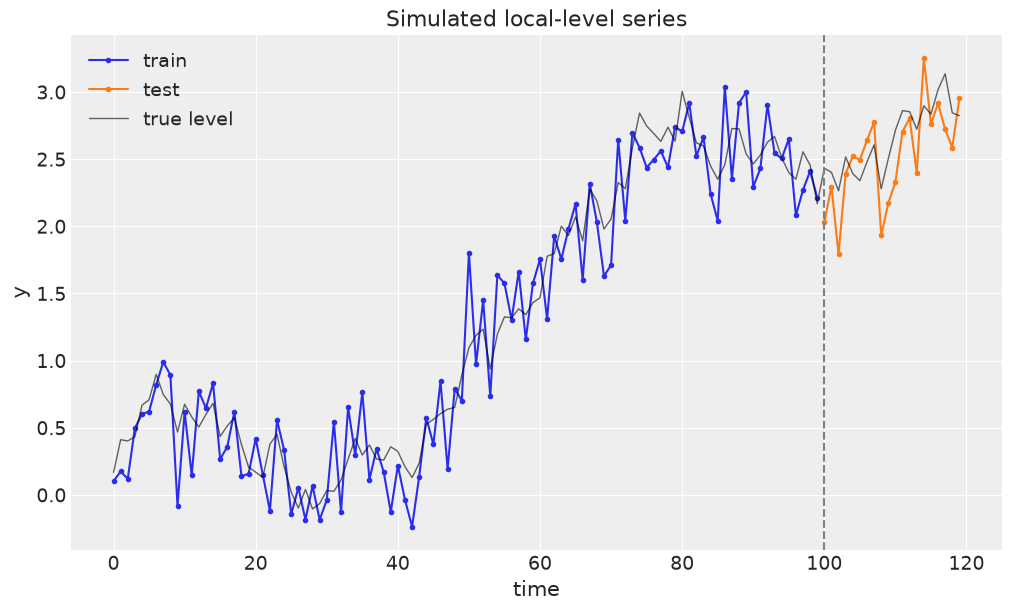

In [2]:
SIGMA_LEVEL = 0.15
SIGMA_OBS = 0.3

n = 120
n_train = 100
future = n - n_train

level_true = np.cumsum(rng.normal(0.0, SIGMA_LEVEL, size=n))
y = level_true + rng.normal(0.0, SIGMA_OBS, size=n)

t = np.arange(n)
train_data = xr.DataArray(y[:n_train], dims=(TIME_DIM,), coords={TIME_DIM: t[:n_train]})
test_data = xr.DataArray(y[n_train:], dims=(TIME_DIM,), coords={TIME_DIM: t[n_train:]})
covariates_full = null_covariates(t)

fig, ax = plt.subplots()
ax.plot(t[:n_train], y[:n_train], "o-", color="C0", markersize=3, label="train")
ax.plot(t[n_train:], y[n_train:], "o-", color="C1", markersize=3, label="test")
ax.plot(t, level_true, color="black", linewidth=1, alpha=0.6, label="true level")
ax.axvline(n_train, color="gray", linestyle="--")
ax.legend(loc="upper left")
ax.set(title="Simulated local-level series", xlabel="time", ylabel="y")
plt.show()

## Model 1: scan-based Markov latent

`markov_time_series` samples the level path step by step with `pytensor.scan`; the
forecast segment is a second scan seeded from the final in-sample level. All 100
per-step latents are parameters of the NUTS run.

In [3]:
def scan_local_level(h: Horizon, covariates: xr.DataArray) -> None:
    sigma_level = pm.HalfNormal("sigma_level", 0.5)
    sigma_obs = pm.HalfNormal("sigma_obs", 0.5)
    level_init = pm.Normal("level_init", 0.0, 1.0)
    level = markov_time_series(
        h,
        "level",
        level_init,
        lambda z_prev, sigma: pm.Normal.dist(z_prev, sigma),
        params=(sigma_level,),
    )

    def obs_fn(name, mu, dims, observed):
        return pm.Normal(name, mu, sigma_obs, dims=dims, observed=observed)

    predict(h, obs_fn, level)


start = perf_counter()
scan_forecaster = HMCForecaster(
    scan_local_level,
    train_data,
    covariates_full,
    draws=1000,
    tune=1000,
    chains=4,
    random_seed=SEED,
    sample_kwargs={"target_accept": 0.95},
)
scan_fit_seconds = perf_counter() - start
print(f"scan model fit: {scan_fit_seconds:.1f}s")

scan model fit: 6.1s


## Model 2: statespace local level

The same dynamics as a `pymc_extras.statespace` structural model:
`LevelTrend(order=1, innovations_order=[1])` is exactly a random-walk level, plus
`MeasurementError` for $\sigma_\varepsilon$. The Kalman filter integrates the level path
out analytically, so NUTS samples only the three structural parameters. The initial state
covariance `P0` is fixed near zero so the initial state is effectively the sampled
`initial_level_trend` — the exact counterpart of the scan model's `level_init`.

The `StatespaceModel` definition mirrors the statespace lifecycle: `statespace()` builds
the component graph, `priors()` declares the parameter priors (matched to the scan model's
priors above).

In [4]:
class StatespaceLocalLevel(StatespaceModel):
    def statespace(self, data, covariates):
        level = st.LevelTrend(order=1, innovations_order=[1])
        return (level + st.MeasurementError()).build(verbose=False)

    def priors(self, ss_mod, data, covariates):
        # P0 ~ 0 pins the initial state to initial_level_trend ~ N(0, 1),
        # matching the scan model's level_init prior exactly
        pm.Deterministic("P0", 1e-4 * pt.eye(ss_mod.k_states), dims=("state", "state_aux"))
        pm.Normal("initial_level_trend", 0.0, 1.0, dims="state_level_trend")
        pm.HalfNormal("sigma_level_trend", 0.5, dims="shock_level_trend")
        pm.HalfNormal("sigma_MeasurementError", 0.5)


start = perf_counter()
ss_forecaster = StatespaceForecaster(
    StatespaceLocalLevel(),
    train_data,
    covariates_full,
    draws=1000,
    tune=1000,
    chains=4,
    random_seed=SEED,
    sample_kwargs={"target_accept": 0.95},
)
ss_fit_seconds = perf_counter() - start
print(f"statespace model fit: {ss_fit_seconds:.1f}s")

statespace model fit: 7.3s


## Posterior quality

Both models estimate the same two scales. The table compares their posteriors against the
truth, along with effective sample sizes and sampling efficiency (ESS per second — the
number that actually matters when the two runs cost different amounts of wall clock).

In [5]:
scan_post = scan_forecaster.idata.posterior
ss_post = ss_forecaster.idata.posterior

pairs = [
    (
        "sigma_level",
        scan_post["sigma_level"],
        ss_post["sigma_level_trend"].squeeze("shock_level_trend", drop=True),
        SIGMA_LEVEL,
    ),
    ("sigma_obs", scan_post["sigma_obs"], ss_post["sigma_MeasurementError"], SIGMA_OBS),
]

rows = []
for name, scan_da, ss_da, truth in pairs:
    for model, da, seconds in [
        ("scan", scan_da, scan_fit_seconds),
        ("statespace", ss_da, ss_fit_seconds),
    ]:
        ess = float(az.ess(da.rename(name)).to_array().squeeze())
        rows.append(
            {
                "parameter": name,
                "model": model,
                "truth": truth,
                "posterior mean": float(da.mean()),
                "posterior sd": float(da.std()),
                "ess_bulk": round(ess),
                "ess / second": round(ess / seconds, 1),
            }
        )

pd.DataFrame(rows).set_index(["parameter", "model"]).round(3)

truth  posterior mean  posterior sd  ess_bulk  \
parameter   model                                                       
sigma_level scan         0.15           0.146         0.027       464   
            statespace   0.15           0.145         0.028      3338   
sigma_obs   scan         0.30           0.279         0.026      2907   
            statespace   0.30           0.280         0.026      3386   

                        ess / second  
parameter   model                     
sigma_level scan                76.3  
            statespace         458.2  
sigma_obs   scan               477.7  
            statespace         464.7

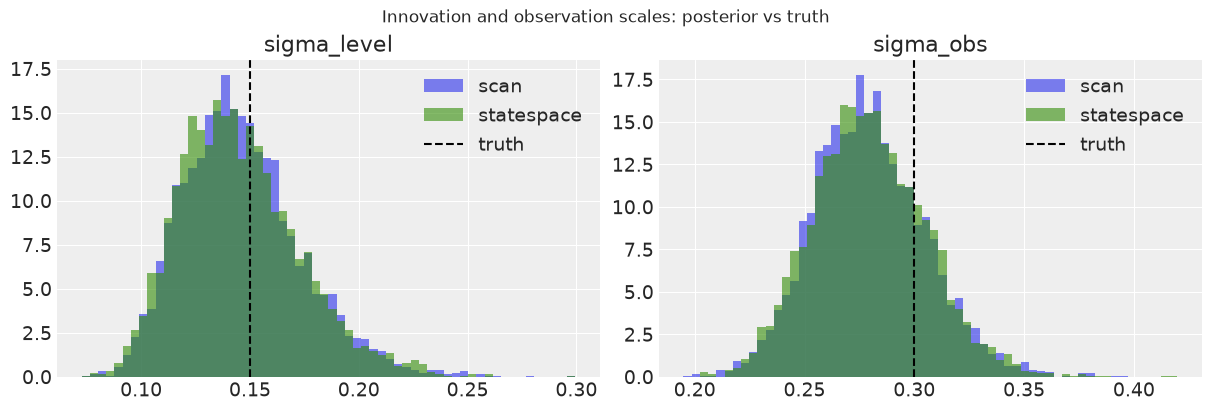

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, scan_da, ss_da, truth) in zip(axes, pairs, strict=True):
    bins = np.histogram_bin_edges(np.r_[scan_da.values.ravel(), ss_da.values.ravel()], bins=60)
    ax.hist(scan_da.values.ravel(), bins=bins, density=True, alpha=0.6, color="C0", label="scan")
    ax.hist(
        ss_da.values.ravel(), bins=bins, density=True, alpha=0.6, color="C2", label="statespace"
    )
    ax.axvline(truth, color="black", linestyle="--", label="truth")
    ax.set_title(name)
    ax.legend()
fig.suptitle("Innovation and observation scales: posterior vs truth")
plt.show()

Both posteriors land on the truth, but the *sampling efficiency* differs sharply on the
innovation scale $\sigma_\eta$: sampling per-step latents couples the level path with its
scale in a funnel-like geometry that NUTS has to fight through (low ESS despite 4000
draws), while the marginalized likelihood removes those latents entirely. At this series
length the wall-clock per fit is compile-dominated and similar; the ESS-per-second gap is
what grows as series get longer and models gain more per-step latents.

## Forecasts

Both forecasters expose the same `forecast` API and return the same labeled
`predictions` group, so evaluation code does not care which one produced it.

In [7]:
num_samples = 1000
scan_pred = scan_forecaster.forecast(covariates_full, num_samples=num_samples, random_seed=SEED)
ss_pred = ss_forecaster.forecast(covariates_full, num_samples=num_samples, random_seed=SEED)

scan_fc = scan_pred["predictions"]["forecast"]
ss_fc = ss_pred["predictions"]["forecast"]

scores = pd.DataFrame(
    {
        "scan": evaluate_forecast(scan_fc, test_data.rename({TIME_DIM: FUTURE_DIM})),
        "statespace": evaluate_forecast(ss_fc, test_data.rename({TIME_DIM: FUTURE_DIM})),
    }
)
scores.round(3)

,scan,statespace
mae,0.356,0.349
rmse,0.421,0.421
crps,0.241,0.245
coverage,1.000,1.000


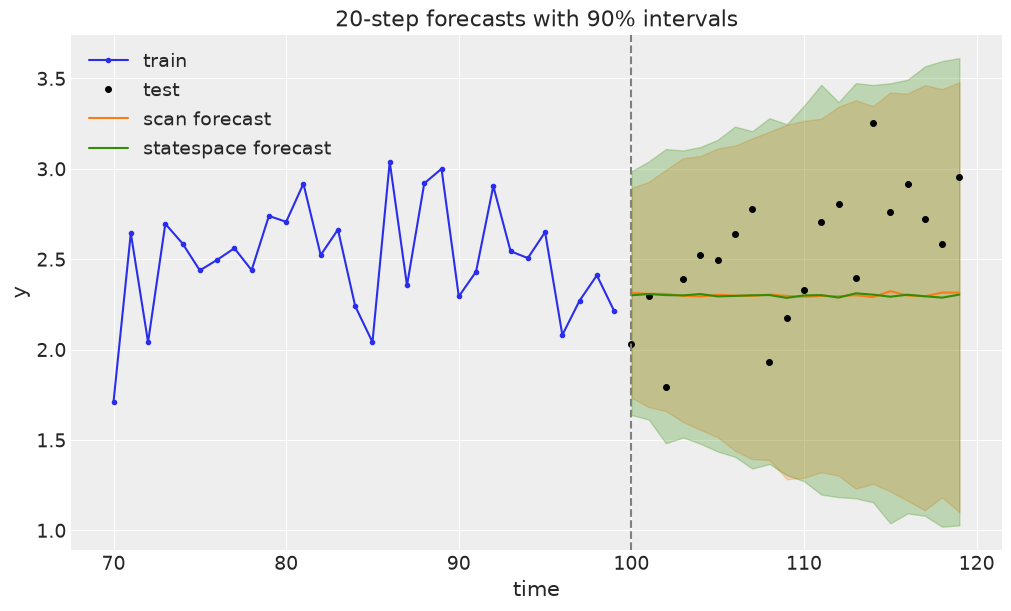

In [8]:
fig, ax = plt.subplots()
ax.plot(t[70:n_train], y[70:n_train], "o-", color="C0", markersize=3, label="train")
ax.plot(t[n_train:], y[n_train:], "o", color="black", markersize=4, label="test")
for fc, color, label in [(scan_fc, "C1", "scan"), (ss_fc, "C2", "statespace")]:
    stacked = fc.stack(sample=("chain", "draw"))
    mean = stacked.mean("sample")
    lo, hi = stacked.quantile([0.05, 0.95], dim="sample").values
    ax.plot(fc[FUTURE_DIM].values, mean, color=color, label=f"{label} forecast")
    ax.fill_between(fc[FUTURE_DIM].values, lo, hi, color=color, alpha=0.25)
ax.axvline(n_train, color="gray", linestyle="--")
ax.legend(loc="upper left")
ax.set(title="20-step forecasts with 90% intervals", xlabel="time", ylabel="y")
plt.show()

## One `backtest` call for both

The point of the interop: `backtest` takes `forecaster_cls=` and per-window options, so a
statespace structural model is scored over the same moving windows, with the same metrics,
as a hand-written forecasting model. (Window schedules are reduced here to keep the
notebook quick.)

In [9]:
window_kwargs = dict(
    min_train_window=80,
    test_window=20,
    stride=20,
    num_samples=500,
    random_seed=SEED,
)

fit_options = {
    "draws": 500,
    "tune": 500,
    "chains": 2,
    "sample_kwargs": {"target_accept": 0.95},
}
scan_results = backtest(
    y,
    None,
    scan_local_level,
    forecaster_cls=HMCForecaster,
    forecaster_options=fit_options,
    **window_kwargs,
)
ss_results = backtest(
    y,
    None,
    StatespaceLocalLevel(),
    forecaster_cls=StatespaceForecaster,
    forecaster_options=fit_options,
    **window_kwargs,
)

comparison = pd.concat(
    {
        "scan": results_to_dataframe(scan_results).set_index("t1"),
        "statespace": results_to_dataframe(ss_results).set_index("t1"),
    },
    names=["model"],
)
columns = ["t0", "t2", "mae", "rmse", "crps", "coverage", "train_walltime", "test_walltime"]
comparison[columns].round(3)

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


t0   t2    mae   rmse   crps  coverage  train_walltime  \
model      t1                                                            
scan       80    0  100  0.259  0.303  0.200       1.0           1.889   
           100   0  120  0.350  0.425  0.241       1.0           2.641   
statespace 80    0  100  0.253  0.297  0.204       1.0           3.669   
           100   0  120  0.349  0.425  0.247       1.0           4.277   

                test_walltime  
model      t1                  
scan       80           0.064  
           100          0.066  
statespace 80           0.651  
           100          0.676

## Takeaways

- **Same protocol**: `StatespaceForecaster` satisfies the forecaster interface, so
  statespace models drop into `forecast`, `predict_in_sample`, `backtest`, and the metrics
  layer unchanged.
- **Better sampling for linear-Gaussian dynamics**: Kalman-filter marginalization removes
  the per-step latents from the sampling problem — several-fold more effective samples per
  second on the innovation scale (~7x the bulk ESS in this run), with forecasts and
  calibration on par. (On a 100-step series the total wall clock is compile-dominated and
  similar; the efficiency gap is what scales.)
- **When to scan**: `markov_time_series` remains the tool for *nonlinear* or
  *non-Gaussian* transitions (thresholds, multiplicative dynamics, discrete or heavy-tailed
  innovations) that a linear-Gaussian statespace cannot express.